DSA 410 Final Project

Group members: Luis Tapia, Amulya Bollapragada, Kaushya Bhattu, Mohsin Aurangabadwala, and Kushant Puri

Project Purpose:

Importing some libraries that we may need to use throughout the data exploration process

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import plotly.express as px

Importing the data set with data in mm/dd/yy format

In [2]:
data = pd.read_csv("first_tee_dataset.csv")
data.head()

,Account Name,Campaign,Date,Received
0,ID_0001,2023 Fall Event,11/17/23,10000.0
1,ID_0001,2024 Fall Event,6/26/24,0.0
2,ID_0001,2023 Fall Event,7/18/23,0.0
3,ID_0001,2022 Fall Event,1/23/23,10000.0
4,ID_0001,2022 Fall Event,3/7/22,10000.0


Importing the data set with date in seperate columns for month, day, year

In [3]:
df = pd.read_excel("giving_data.xlsx")
df.head()

,Account Name,Campaign,Month,Day,Year,Received
0,ID_0001,2023 Fall Event,November,17,2023,10000.0
1,ID_0001,2024 Fall Event,June,26,2024,0.0
2,ID_0001,2023 Fall Event,July,18,2023,0.0
3,ID_0001,2022 Fall Event,January,23,2023,10000.0
4,ID_0001,2022 Fall Event,March,7,2022,10000.0


First question of interest: What percentage of donors increased, decreased or maintained their gift amount year over year? Who were those donors?

Our ideas is to find rate of change of donation amount for each individual donor. 
We will be looking at each donor and investigating...
    As date increases, how does the donation amount change?

The following code will be used to calculate the "slope" or rate of change of donation amount for each donor. 
We will place this information into a data frame.

In [4]:
# We are converting the Date variable to datetime format so Python can perform calculations on the dates
data['Date'] = pd.to_datetime(data['Date'])  

#This is the list we will append the rate of change for donations of each donor (along with other important info)
slopes = []   

for donor, group in data.groupby('Account Name'):
    #If someone attended an event, but did not donate, those observations are excluded because they don't count as donations (don't want them to affect our slope)
    group = group[group['Received'] > 0] 
    #If a single donor donated two seperate times on the same date, then those donations are combined into one donation
    group = group.groupby('Date', as_index=False)['Received'].sum() 
    #If someone donated at least two times on two seperate dates, we will proceed with calculating the rate of change of their donation amount
    #We need this if statement because someone needs to have donated at least twice on two seperate days in order to calculate rate of change over time
    if len(group) >= 2 and group['Date'].nunique() > 1:
        #Instead of using the actual dates as the x values when calculating our slope, we are using the number of days since the person's first donation, to give simpler numbers but the same result
        x = (group['Date'] - group['Date'].min()).dt.days
        y = group['Received']

        # fit a simple linear regression: y = slope * x + intercept
        slope, intercept, r_value, p_value, stderr = linregress(x, y)

        #Append information about each donor and the rate of change of their donation amount to our list
        slopes.append({
            'DonorID': donor,
            'slope_of_donations': slope,
            'intercept': intercept,
            'r_value': r_value,
            'p_value': p_value,
            'stderr': stderr,
            'n_obs': len(group)
        })
    else:
        #If donors only made a single donation, we can't calculate rate of change so all values as na
        slopes.append({
            'DonorID': donor,
            'slope_of_donations': np.nan,
            'intercept': np.nan,
            'r_value': np.nan,
            'p_value': np.nan,
            'stderr': np.nan,
            'n_obs': len(group)
        })

#Here is the final data frame that contains all DonorIDs and their "slopes"
slope_df = pd.DataFrame(slopes)


/var/folders/qn/pr1whzk53j13xb8ckndcf06c0000gn/T/ipykernel_71459/1134987202.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


We want to create a new variable that identifies whether an individual's donations were on an increasing trend, decreasing trend, or was consistently maintained. This is important to find in order to answer our original question.
We are determining this based on the distance of a donor's "slope" from 0.

In [11]:
# If donors did not have a slope due to only donating one time, we are not considering them 
slope_df_nonan = slope_df.dropna(subset=['slope_of_donations'])

directions = []

#We are looping through each row of our dataframe that includes all rows that have a valid rate of change of donation amount
    #index refers to the index of a specific row
    #row refers to the actual values in that row
for index, row in slope_df_nonan.iterrows():
    #We are taking the value of the slope in a specific row
    slope = row['slope_of_donations']

    #Chose to consider all slopes above 0.08 an increasing rate of change
    #Chose to consider all slopes below -0.08 a decreasing rate of change
    #Chose to consider all slopes above -0.08 and and below 0.08 a maintained rate of change

    if slope < -0.08:
        directions.append('decreasing')
    elif -0.08 <= slope <= 0.08:
        directions.append('maintained')
    else:
        directions.append('increasing')

#We now have a list classifying the direction of rate of change of donation amount for each donor
slope_df_nonan['direction'] = directions

/var/folders/qn/pr1whzk53j13xb8ckndcf06c0000gn/T/ipykernel_71459/3109030023.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Now, we have classified each donor's rate of change of donation amount as either increasing, decreasing, or maintained.
We can figure out the percentage of donors in each rate of change category. This gives us a better idea of overall donor activity.

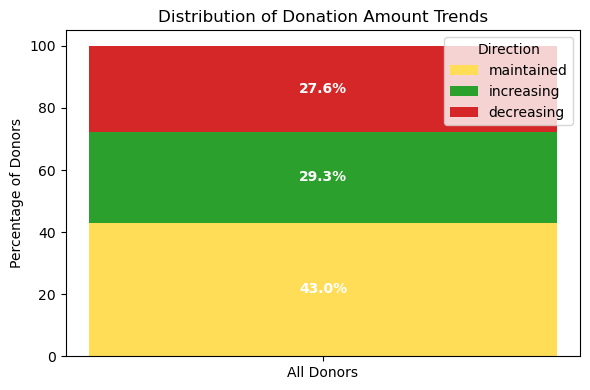

In [18]:
#We wil count how many donors were in each rate of change category as a proportion and turn that information into a data frame
direction_counts = (
    slope_df_nonan['direction']
    .value_counts(normalize=True)
    .reset_index()
)

#Turn the proportions into percentages
direction_counts.columns = ['direction', 'percent']
direction_counts['percent'] *= 100

# Colors for each direction
colors = {
    'increasing': '#2ca02c',   # green
    'maintained': '#ffdd57',   # yellow
    'decreasing': '#d62728'    # red
}

# Create the figure
fig, ax = plt.subplots(figsize=(6,4))

#Starting point for stacking
bottom = 0

#For each row in our data frame that has percentages, we are creating a new bar that shows the percentage of observations in that rate of change category
for index, row in direction_counts.iterrows():
    ax.bar(
        'All Donors',
        row['percent'],
        bottom=bottom,
        label=row['direction'],
        color=colors[row['direction']]
    )
    bottom += row['percent']

# Add labels
ax.set_ylabel("Percentage of Donors")
ax.set_title("Distribution of Donation Amount Trends")
ax.legend(title="Direction")

# Add percent labels inside the bar
bottom = 0
for _, row in direction_counts.iterrows():
    ax.text(
        x=0,
        y=bottom + row['percent']/2,
        s=f"{row['percent']:.1f}%",
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )
    bottom += row['percent']

plt.tight_layout()
plt.show()

There is also another part of the question that we have yet to answer. 
    Which specific individuals had the greatest rate of increase of donation amount?
    Which specific individuals had the greatest rate of decrease of donation amount?

In [21]:
#These were the top 10 donors that had the greatest rate of INCREASE in their donation amount
    #If you want to know the top 5,20,50, etc. you can simply change the number in the code
top10 = slope_df_nonan.nlargest(10, 'slope_of_donations')
top10

#These were the top 10 donors that had the greatest rate of DECREASE in their donation amount
    #If you want to know the top 5,20,50, etc. you can simply change the number in the code
low10 = slope_df_nonan.nsmallest(10, 'slope_of_donations')
low10


,DonorID,slope_of_donations,intercept,r_value,p_value,stderr,n_obs,direction
917,ID_0918,-1036.580000,1555.030000,-1.000000,0.0000,0.000000,2,decreasing
19,ID_0020,-466.336667,3109.210000,-1.000000,0.0000,0.000000,2,decreasing
2729,ID_2730,-105.277234,10000.000000,-1.000000,0.0000,0.000000,2,decreasing
1320,ID_1321,-100.000000,200.000000,-1.000000,0.0000,0.000000,2,decreasing
1157,ID_1158,-97.208333,3333.000000,-1.000000,0.0000,0.000000,2,decreasing
2440,ID_2441,-93.508000,617.540000,-1.000000,0.0000,0.000000,2,decreasing
628,ID_0629,-90.255806,3109.120000,-1.000000,0.0000,0.000000,2,decreasing
2073,ID_2074,-77.728346,15461.417016,-0.999639,0.0171,2.088365,3,decreasing
1690,ID_1691,-60.000000,1000.000000,-1.000000,0.0000,0.000000,2,decreasing
2167,ID_2168,-57.642113,8600.000000,-1.000000,0.0000,0.000000,2,decreasing


Moving onto to second question of interest: What are the retention rates of donors year over year? Who are the donors we lost, and who did we retain?

Here is how we will be calculating retention rate:

Since there are only 3 years (2022, 2023, and 2024), if we did retention rate from year to year, we would only be able to calculate 2 retention rates:
    - Retention rate from 2022 to 2023
    - Rentention rate from 2023 to 2024

Therefore, we decided to calculate retention rate from quarter to quarter to get a better idea of commitment of donors overtime.

In [8]:
#We are creating a new column in our data frame that indicates what quarter of what year a donation came from
data['Quarter'] = (
    data['Date'].dt.year.astype(str) 
    + ' - Quarter ' 
    + data['Date'].dt.quarter.astype(str)
)

#We are only counting non zero donations as donations. 
#We suspect that the donations of 0 come from individuals that attended an event but did not donate
nonzero_donations = data[data['Received'] > 0]

#We are finding the set of donors that donated in each quarter
quarter_donors = nonzero_donations.groupby('Quarter')['Account Name'].apply(set)

#Getting a list of unique values of the quarters (in chronological order) that we will use to calculate retention rates
quarters = sorted(quarter_donors.index)

#We are creating an empty list to contain the retention rates from quarter to quarter
retention_sets = []

#We will loop through each quarter to find the retention rate of donors between that quarter and the next quarter
#This is why we are only going until the second to last quarter, because the last quarter in our data set doesn't have a "next" quarter
for i in range(len(quarters) - 1):
    #Labeling one quarter as our previous quarter
    prev_q = quarters[i]
    #Labeling the quarter that comes next chronologically as the current quarter
    curr_q = quarters[i + 1]

    #Finding the set of donors who donated in the previous quarter and the current quarter
    prev_donors = quarter_donors[prev_q]
    curr_donors = quarter_donors[curr_q]

    #The returning donors are those who donated in the previous quarter and the current quarter
    returning_donors = prev_donors & curr_donors

    #The lost donors are those who donated in the previous quarter but not the current quarter
    lost_donors = prev_donors - curr_donors

    #If there are a non zero number of donors in the previous quarter, we will find the percentage of individuals who returned as donors from the previous quarter to the next
    if len(prev_donors) > 0:
        retention_rate = (len(returning_donors) / len(prev_donors)) * 100
    else:
        retention_rate = np.nan

    #Creating a shorter way to display the range of quarters we are calculating retention rate on
    prev_short = "Q" + prev_q[-1] + " '" + prev_q[2:4]
    curr_short = "Q" + curr_q[-1] + " '" + curr_q[2:4]
    short_range = f"{prev_short} - {curr_short}"

    #We will save a list of dictionaries 
        #Each dictionary has information about the retention rate between each quarter
    retention_sets.append({
        'from_quarter': prev_q,
        'to_quarter': curr_q,
        'retention_rate': retention_rate,
        'prev_donors': len(prev_donors),
        'returning_donors': len(returning_donors),
        'quarter_range_short': short_range,  
        'retained_donors': returning_donors,
        'lost_donors': lost_donors
    })

#We are saving the information in this list of dictionaries as a data frame
retention_df = pd.DataFrame(retention_sets)

Now let's display the change in retention rate from quarter to quarter in a line chart

In [15]:
#Creating the scatter plot
    #The plot is interactive, as you hover over each dot, you will see...
        #number of donors in the previous quarter
        #number of donors that returned for the next quarter
        #exact retention rate
    #The dots are also color coded by retention rate, giving a more visual representation of how retention rate has changed overtime
fig = px.scatter(
    retention_df,
    x='quarter_range_short',
    y='retention_rate',
    color='retention_rate',
    color_continuous_scale='Viridis',
    hover_data={
        'prev_donors': True,
        'returning_donors': True,
        'retention_rate': ':.2f'
    },
    title='Donor Retention Rates Quarter to Quarter'
)

# Make dots bigger so you can see the color
fig.update_traces(marker=dict(size=14))

# Add connecting line
fig.add_traces(px.line(
    retention_df,
    x='quarter_range_short',
    y='retention_rate'
).data)

fig.update_layout(xaxis_tickangle=-45)
fig.show()


In [13]:
#We are only counting non zero donations as donations. 
#We suspect that the donations of 0 come from individuals that attended an event but did not donate
nonzero_donations2 = df[df['Received'] > 0]

#We are finding the set of donors that donated in each year
yearly_donors = nonzero_donations2.groupby('Year')['Account Name'].apply(set)

#Getting a list of unique values of the years (in chronological order) that we will use to calculate retention rates year to year
years = sorted(yearly_donors.index)

#We are creating an empty list to contain the retention rates from year to year
retention_sets2 = []

#We will loop through each year to find the retention rate of donors between that year and the next year
#This is why we are only going until the second to last year, because the last year in our data set doesn't have a "next" year
for i in range(len(years) - 1):
    #Labeling one year as our previous year
    prev_y = years[i]
    #Labeling the year that comes next chronologically as the current year
    curr_y = years[i + 1]

    #Finding the set of donors who donated in the previous year and the current year
    prev_donors = yearly_donors[prev_y]
    curr_donors = yearly_donors[curr_y]

    #The returning donors are those who donated in the previous year and the current year
    returning_donors = prev_donors & curr_donors

    #The lost donors are those who donated in the previous year but not the current year
    lost_donors = prev_donors - curr_donors

    #If there are a non zero number of donors in the previous year, we will find the percentage of individuals who returned as donors from the previous year to the next
    if len(prev_donors) > 0:
        retention_rate = (len(returning_donors) / len(prev_donors)) * 100
    else:
        retention_rate = np.nan

    #Creating a way to display the range of years we are calculating retention rate on
    short_range = f"{prev_y} - {curr_y}"

    #We will save a list of dictionaries 
        #Each dictionary has information about the retention rate between each year
    retention_sets2.append({
        'from_year': prev_y,
        'to_year': curr_y,
        'retention_rate': retention_rate,
        'prev_donors': len(prev_donors),
        'returning_donors': len(returning_donors),
        'year_range_short': short_range,  
        'retained_donors': returning_donors,
        'lost_donors': lost_donors
    })

#We are saving the information in this list of dictionaries as a data frame
retention_df2 = pd.DataFrame(retention_sets2)

In [14]:
print(years)

[2022, 2023, 2024]


Which donors stuck with us through it all? Let's call these individuals our "Golden Donors" 
    We will calculate this by finding the set of donors that donated in every quarter from 2021-2024

In [10]:
golden_donors = (quarter_donors.iloc[1] &
                 quarter_donors.iloc[2] &
                 quarter_donors.iloc[3] &
                 quarter_donors.iloc[4] &
                 quarter_donors.iloc[5] &
                 quarter_donors.iloc[6] &
                 quarter_donors.iloc[7] &
                 quarter_donors.iloc[8] &
                 quarter_donors.iloc[9] &
                 quarter_donors.iloc[10] &
                 quarter_donors.iloc[11])

print(golden_donors)

{'ID_0423', 'ID_2429', 'ID_1498', 'ID_2721', 'ID_1791', 'ID_0630', 'ID_0817', 'ID_0277', 'ID_2776', 'ID_1594', 'ID_2727', 'ID_2448', 'ID_2796', 'ID_2671', 'ID_2482', 'ID_2006', 'ID_1300', 'ID_2201'}


You may also have a lot of other questions about the specific donors we lost/gained between individual years and individual quarters. 

These lists can be too long to display in a presentation format, but is still useful information to have. 

Thus, we have put together an excel spreadsheet that includes a list of lost and returning donors between individual years and individual quarters.

The link to the spreadsheet can be found here:

https://docs.google.com/spreadsheets/d/1U0iI4MniTMMfPR-i8VZuOJOtnw2mvyEMykW_WYzQEzI/edit?usp=sharing